In [12]:
# 1. Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, roc_auc_score, mean_squared_error, r2_score
)
import seaborn as sns

In [13]:

# 2. Load dataset
df = pd.read_csv("C:\\Users\\Hii\\Downloads\\Medicaldataset.csv")
print(df.info())

# 3. View unique values in target column
print("Unique values in 'Heart Attack Risk':", df['Heart Attack Risk'].unique())

# 4. Convert 'Negative' to 0 and 'Positive' to 1
df['Heart Attack Risk'] = df['Heart Attack Risk'].str.strip().str.capitalize()

df['Heart Attack Risk'] = df['Heart Attack Risk'].map({'Negative': 0, 'Positive': 1})
print(df.info())
# 5. Drop rows with NaN in target column (due to mapping issues)
df = df.dropna(subset=['Heart Attack Risk'])


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1319 non-null   int64  
 1   Gender                    1319 non-null   int64  
 2   Heart rate                1319 non-null   int64  
 3   Systolic blood pressure   1319 non-null   int64  
 4   Diastolic blood pressure  1319 non-null   int64  
 5   Blood sugar               1319 non-null   float64
 6   CK-MB                     1319 non-null   float64
 7   Troponin                  1319 non-null   float64
 8   Heart Attack Risk         1319 non-null   object 
dtypes: float64(3), int64(5), object(1)
memory usage: 92.9+ KB
None
Unique values in 'Heart Attack Risk': ['negative' 'positive']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype 

In [14]:

# 6. Define features and target
X = df.iloc[:, :-1] 
y = df.iloc[:, -1]

# 7. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

In [15]:

# 8. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==============================
# 9. Logistic Regression
# ==============================
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)
log_pred = log_reg.predict(X_test_scaled)

print("\nLogistic Regression Accuracy:", accuracy_score(y_test, log_pred))
print("\nClassification Report:\n", classification_report(y_test, log_pred))

log_probs = log_reg.predict_proba(X_test_scaled)[:, 1]
fpr_log, tpr_log, _ = roc_curve(y_test, log_probs)
roc_auc_log = roc_auc_score(y_test, log_probs)



Logistic Regression Accuracy: 0.8106060606060606

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.74      0.75       151
           1       0.84      0.85      0.85       245

    accuracy                           0.81       396
   macro avg       0.80      0.80      0.80       396
weighted avg       0.81      0.81      0.81       396



In [16]:

# ==============================
# 10. Multiple Linear Regression
# ==============================
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)
lin_pred_cont = lin_reg.predict(X_test_scaled)
lin_pred_bin = (lin_pred_cont >= 0.5).astype(int)

print("\nLinear Regression Accuracy:", accuracy_score(y_test, lin_pred_bin))
print("MSE:", mean_squared_error(y_test, lin_pred_cont))
print("R² Score:", r2_score(y_test, lin_pred_cont))

fpr_lin, tpr_lin, _ = roc_curve(y_test, lin_pred_cont)
roc_auc_lin = roc_auc_score(y_test, lin_pred_cont)



Linear Regression Accuracy: 0.7272727272727273
MSE: 0.1906842840566792
R² Score: 0.1917192407451761


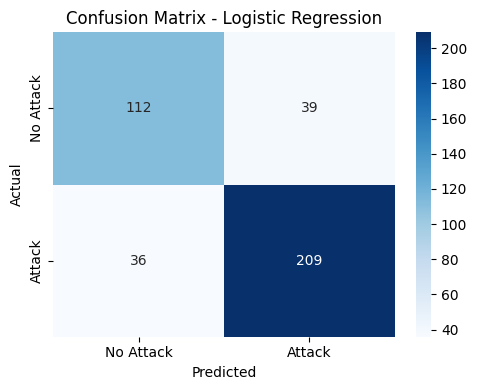


True Negatives: 112
False Positives: 39
False Negatives: 36
True Positives: 209


In [17]:

# Confusion Matrix with values shown
cm = confusion_matrix(y_test, log_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['No Attack', 'Attack'],
            yticklabels=['No Attack', 'Attack'])

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives: {tp}")


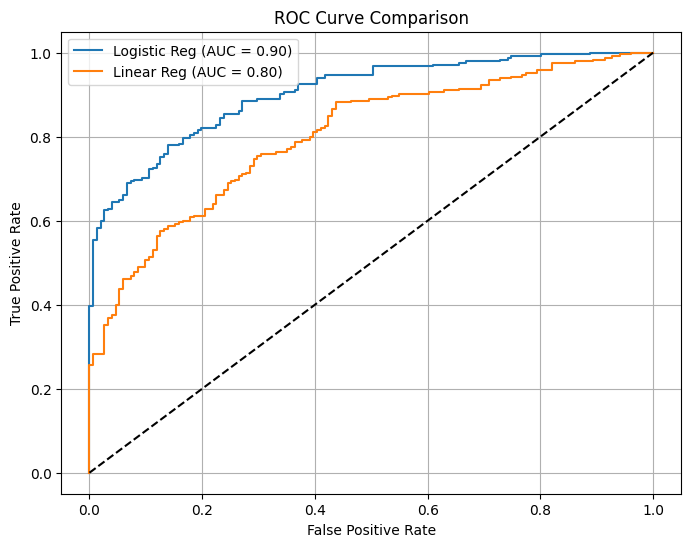

In [18]:

# ==============================
# 12. ROC Curve Comparison
# ==============================
plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, label='Logistic Reg (AUC = %.2f)' % roc_auc_log)
plt.plot(fpr_lin, tpr_lin, label='Linear Reg (AUC = %.2f)' % roc_auc_lin)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()


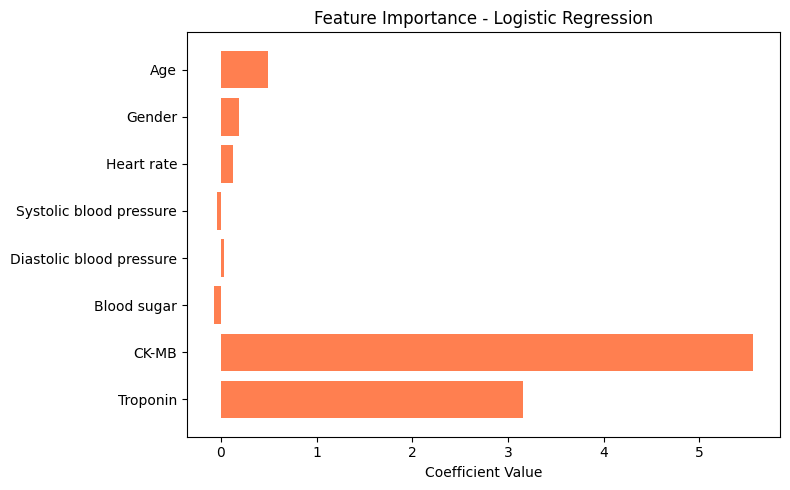

In [23]:

# ==============================
# 13. Feature Importance (Logistic Regression Coefficients)
# ==============================
coef = log_reg.coef_[0]
features = X.columns

plt.figure(figsize=(8, 5))
plt.barh(features, coef, color='coral')
plt.title("Feature Importance - Logistic Regression")
plt.xlabel("Coefficient Value")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


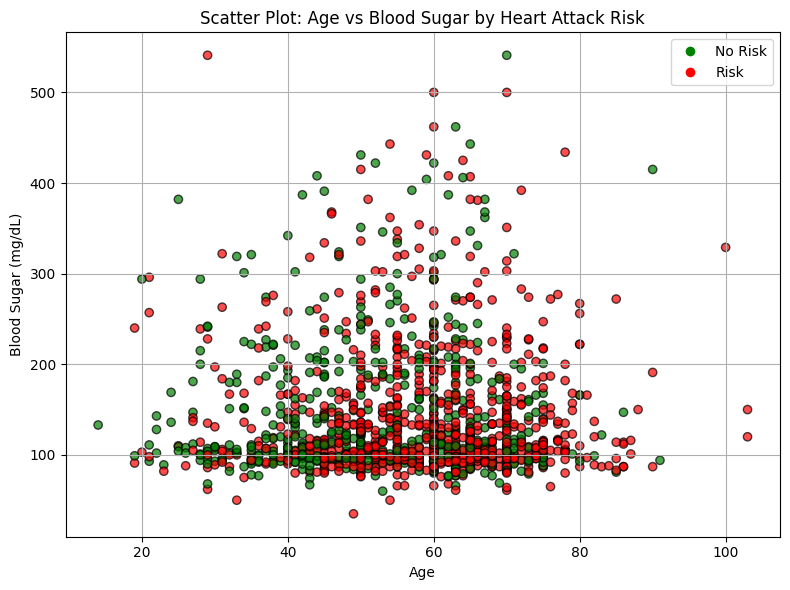

['scaler.pkl']

In [20]:
 # Scatter plot: Age vs Blood Sugar colored by Heart Attack Risk
plt.figure(figsize=(8, 6))
colors = {0: 'green', 1: 'red'}  # 0: No Attack, 1: Attack

plt.scatter(
    df['Age'], 
    df['Blood sugar'], 
    c=df['Heart Attack Risk'].map(colors),
    alpha=0.7,
    edgecolors='k',
    label='Data points'
)

plt.title('Scatter Plot: Age vs Blood Sugar by Heart Attack Risk')
plt.xlabel('Age')
plt.ylabel('Blood Sugar (mg/dL)')
plt.grid(True)

# Legend for colors
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='No Risk', markerfacecolor='green', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Risk', markerfacecolor='red', markersize=8)
]
plt.legend(handles=legend_elements)
plt.tight_layout()
plt.show()
import joblib

# Save trained models
joblib.dump(log_reg,"logistic_model.pkl")
joblib.dump(scaler,"scaler.pkl")

<Axes: >

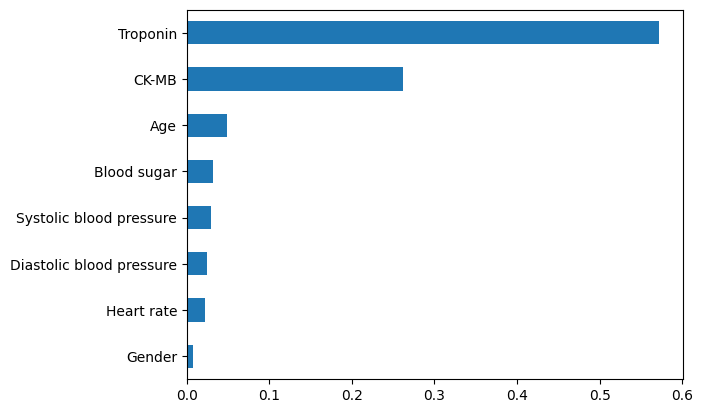

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

importance = rf.feature_importances_

feature_importance = pd.Series(importance, index=X.columns)
feature_importance.sort_values().plot(kind='barh')

Text(0.5, 1.0, 'Feature Correlation')

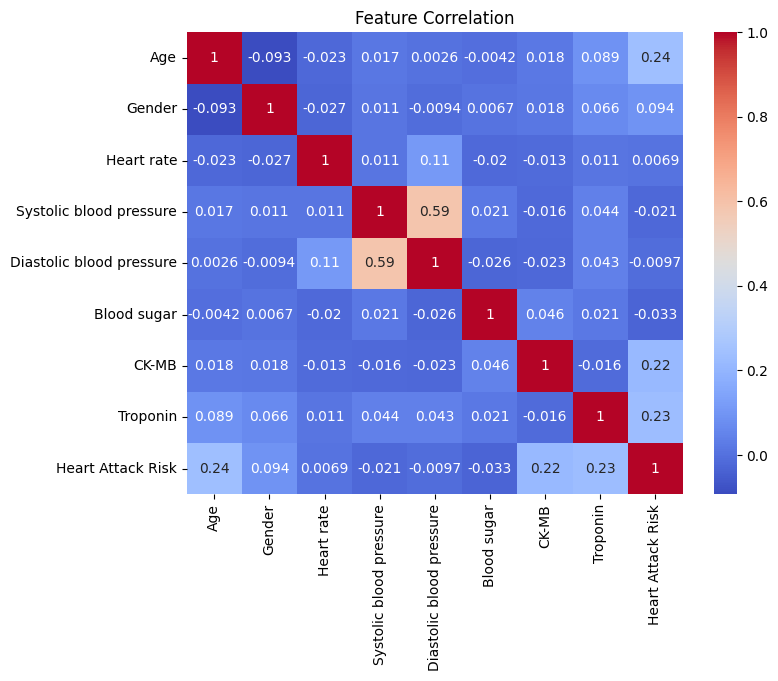

In [25]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")